### GRB spectral fitting: CC + BTO1 + BTO2 (free cross-normalization): GRB090206620

**Purpose.**  
Build a 40 s simulated burst, from responses to fake data, and
compare CC-only and CC+BTO joint spectral constraints. Cross-normalization factors $C_{\rm BTO1}$ and $C_{\rm BTO2}$ are fitted independently over 0.5--1.5, with CC as the reference (factor 1). 

This tutorial is based on COSIpy's example: 
[GRB spectral-fitting example](https://cositools-cosipy.readthedocs.io/en/latest/tutorials/spectral_fits/continuum_fit/grb/SpectralFit_GRB.html)
([original notebook](https://github.com/cositools/cosipy/blob/main/docs/tutorials/spectral_fits/continuum_fit/grb/SpectralFit_GRB.ipynb)).
That example simulates **GRB090206620**, places its source at Galactic
$(l,b)=(93,-53)$ degrees, and supplies its injected Band spectrum. We adopt this
simulated configuration and add BTO1 and BTO2 through the public BTO API and
standard threeML `OGIPLike` plugins. 

The input CC background is **albedo photons**, as explicitly described by
COSIpy's GRB tutorial. It is not a total satellite background.
This example is for the response-consistent joint
fitting; it is not a full-background mission sensitivity forecast.

**Inputs.**  
Set only project_path in Section 1; all input paths are derived from project_path / "response", and the module is in project_path / "api". Use the installed `cosipy` Python
environment (COSIpy, HistPy, NumPy/SciPy, Astropy, h5py, Matplotlib, pandas,
astromodels and threeML). `bto_api_path` points to the importable `bto_response.py` module.

| Path variable | Scientific meaning and use |
|---|---|
| `cc_response_path` | `SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5`: full simulated CC instrument response from incident spacecraft direction/true energy to measured `(Em, Phi, PsiChi)` counts. This COSIpy-distributed response is not observed GRB counts or a one-dimensional ARF/RMF. |
| `orientation_path` | `20280301_3_month_with_orbital_info.fits`: COSIpy/DC3 simulated attitude/orbit/livetime history, including timestamps, X/Z pointing, Earth zenith, altitude and livetime. It transforms the celestial source into spacecraft directions during the ON interval. CC and BTO use the same file. |
| `cc_time_resolved_background_path` | `bkg_binned_data_1s_local.hdf5`: COSIpy GRB example's **albedo-photon** background in one-second Unix-Time bins and local `(Em, Phi, PsiChi)` bins. It supplies measurement-bin definitions and the OFF background distribution, not source counts or a prepared ON observation. |
| `bto_response_h5_path` | `bto_response_order2.h5`: this project's **unsmeared Geant4 deposit response** for BTO1/BTO2 and 192 directions. Gain, energy resolution, measured threshold and saturation are **not** in this file. `get_bto_response` applies the chosen detector effects model before `write_ogip_response` writes the recorded ARF/RMF/RSP. |
| `bto_background_template_path` | `BTO_background_template_10-3000keV.fits`: single-BTO mean background rebuilt from eleven weighted simulation components over 10--3000 keV. The file stores its own `EBOUNDS`, `RATE`, weighted/smoothed expected `COUNTS`, reference exposure and component provenance. The API reads these boundaries and regrids the mean to the requested response; no native-grid constants or external RMF are required. |

The CC axes are aligned to the background file: 10 measured-energy bins
(100--10000 keV), 36 scatter-angle bins and 768 NSIDE=8/RING spacecraft-direction
pixels. The fit uses all `(10,36,768)` bins; count spectra in figures are energy
projections. Background and response/data bin compatibility are preserved by
using these named axes in standard COSIpy interfaces.

**BTO Response levels and detector model.**  
The HDF5 is the reusable deposit library, which contains the unsmeared Geant4 deposit response for BTO1/BTO2 and 192 directions.
The generated OGIP files are source/time-specific **recorded-channel responses**,
already including resolution and acceptance cuts. This notebook explicitly builds
them, rather than assuming they already exist. Defaults are adjustable placeholders:
4096 channels, 0.8125 keV/channel, zero offset/quadratic gain, 30 keV threshold,
3000 keV saturation, and FWHM/E = 65/662 (prototype-anchored approximation).
They are not measured flight calibration. Loading a generated RSP later with
`load_bto_response` does not apply resolution again.

**Workflow.**  
1. **Sections 1--3:** set paths/style, source/time/seeds, detector effects settings and fit
   bounds; define the Band functions.
2. **Section 4:** make fake observations using the CC response and attitude by folding the injected source model, then add source Poisson counts.
3. **Section 5:** select 100 s OFF before and after the 40 s burst, exclude ON,
   estimate ON background by the duration ratio, and add
   source+background to construct the CC observation. Build a standard CC
   Poisson likelihood with an OFF-derived shape and free background rate.
4. **Section 6:** select each BTO separately from the HDF5, average its directional
   response over the source/history, apply the explicit resolution/gain/cuts,
   write OGIP ARF/RMF/RSP and inspect the effective areas.
5. **Section 7:** regrid the BTO mean background, generate independent BTO1/BTO2
   fake PHAs and instantiate the standard threeML plugins.
6. **Sections 8--10:** define minimal local profile utilities, then fit and profile
   CC only and CC+BTO1+BTO2, sharing Band parameters.
7. **Sections 11--13:** compare parameter intervals, likelihood curves, incident
   photon spectra and recorded count spectra directly from memory. Photon
   shading is a marginal-profile-range envelope, not simultaneous 95% coverage.

**Outputs and statistical quantities.**  
`cc_expected_source_values`: expected source counts in each CC bin, from the injected Band model and the CC response.  
`cc_source_fake_values`: fake source counts in each CC bin, generated by adding Poisson noise to the expected source counts.  
`cc_background_fake_values`: fake background counts in each CC bin, generated by adding Poisson noise to the expected background counts.  
Their sum in `cc_data.data` is fitted without background subtraction.   

`cc_fit_background_template` supplies a fixed shape, not the random ON background. During fitting, the OFF-derived distribution is normalized to unit sum and its total rate is fitted freely; the random ON-background realization used to generate the fake data is not supplied to the fit.

---- 

#### 1. Imports, inputs and plotting style

Declare file paths here; set numerical source/detector/fit parameters in Sections
2--3. BTO OGIP responses are generated explicitly in Section 6. `STYLE` and
`style_axes` preserve all four plot borders. Set `SUPPRESS_FIT_WARNINGS=False`
for debugging; exceptions and failed profile points remain visible.

In [1]:
OUTPUT_SUBDIRECTORY = 'free_crossnorm'

from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astromodels import Band, Model, PointSource
from astromodels.core.parameter import Parameter
from histpy import Histogram
from IPython.display import display
from threeML import (
    DataList,
    JointLikelihood,
    activate_warnings,
    silence_warnings,
)
from threeML.plugins.OGIPLike import OGIPLike

from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.data_io import EmCDSBinnedData
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import (
    BinnedInstrumentResponse,
    BinnedThreeMLModelFolding,
    BinnedThreeMLPointSourceResponse,
)
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.statistics import PoissonLikelihood

# Change only this root if you move the complete project directory.
project_path = Path('/Users/shunsaku/work/COSI/sim_solar_cosipy/tutorial_grb_fit_with_bto_response')
response_path = project_path / 'response'
bto_api_path = project_path / 'api'
sys.path.insert(0, str(bto_api_path))

from bto_response import (
    BTOCalibration, Prototype_Resolution,
    get_bto_response,
    write_ogip_response,
    get_bto_background,
    write_ogip_background,
    simulate_bto_spectrum,
)

# Three raw CC inputs: instrument response, attitude, and background (also supplies axes).
cc_response_path = response_path / 'SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5'
orientation_path = response_path / '20280301_3_month_with_orbital_info.fits'
cc_time_resolved_background_path = response_path / 'bkg_binned_data_1s_local.hdf5'

# Raw BTO inputs.
bto_response_h5_path = response_path / 'bto_response_order2.h5'
bto_background_template_path = response_path / 'BTO_background_template_10-3000keV.fits'

output_path = project_path / 'notebook_output' / OUTPUT_SUBDIRECTORY
output_path.mkdir(parents=True, exist_ok=True)

STYLE = {
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.minor.size": 5,
    "ytick.minor.size": 5,
    "xtick.top": True,
    "ytick.right": True,
    "savefig.facecolor": "white",
    "font.size": 14,
    "axes.linewidth": 1.5,
    "legend.fancybox": False,
    "axes.spines.top": True,
    "axes.spines.right": True,
}
plt.rcParams.update(STYLE)
plt.rcParams.update({'axes.titlesize': 14, 'figure.titlesize': 14})

# Set False while diagnosing optimizer/model-bound warnings. True keeps a
# tutorial run readable; Python exceptions and failed profile points still show.
SUPPRESS_FIT_WARNINGS = True
if SUPPRESS_FIT_WARNINGS:
    silence_warnings()
else:
    activate_warnings()

def style_axes(ax):
    """Apply the mandatory four-sided frame and inward ticks."""
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
    ax.tick_params(which='both', direction='in', top=True, right=True)

print('Output directory:', output_path)
print('Suppress threeML/astromodels WARNING messages:', SUPPRESS_FIT_WARNINGS)

16:49:20 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=2579020;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=2579021;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=2579029;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=2579030;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=2579039;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=2579040;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

16:49:21 INFO      Starting 3ML!                                                                     ]8;id=2579049;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=2579050;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

WARNING   WARNINGs here are NOT errors                                                      ]8;id=2579058;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=2579059;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

WARNING   No fermitools installed                                              ]8;id=2579123;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=2579124;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=2579132;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=2579133;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=2579140;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=2579141;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=2579148;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=2579149;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

Output directory: /Users/shunsaku/work/COSI/sim_solar_cosipy/tutorial_grb_fit_with_bto_response/notebook_output/free_crossnorm
Suppress threeML/astromodels WARNING messages: True


#### 2. Observation, source, detector, and fit settings

These variables replace the former YAML configuration. The injected spectrum and the fit starting point are intentionally separate. BTO1 and BTO2 use independent responses and independent Poisson seeds.

In [2]:
source_name = 'source'
source_coord = SkyCoord(l=93.0*u.deg, b=-53.0*u.deg, frame='galactic')
tstart = Time('2028-05-22T08:36:50')
exposure_s = 40.0
tstop = tstart + exposure_s*u.s

injected_band = {
    'K': 0.030210450807,
    'alpha': -0.360,
    'xp': 472.34624,
    'beta': -11.921,
}
fit_start = {'K': 0.02, 'alpha': -1.0, 'xp': 450.0, 'beta': -3.0}
fit_bounds = {
    'K': (0.0001, 10.0),
    'alpha': (-1.9, 1.5),
    'xp': (10.0, 10000.0),
    'beta': (-20.0, -2.01),
}
pivot_keV = 500.0

# CC fake-data controls. OFF intervals bracket the ON interval.
cc_poisson_seed = 20280302
cc_off_before_s = 100.0
cc_off_after_s = 100.0

# Detector effects are applied once, during HDF5 -> recorded OGIP construction.
# These are configurable science placeholders, not flight calibration.
bto_calibration = BTOCalibration(
    n_channels=4096, gain_quadratic_ch_per_keV2=0.0,
    gain_slope_ch_per_keV=1.0/0.8125, gain_offset_ch=0.0,
    lower_threshold_keV=30.0, upper_saturation_keV=3000.0,
)
bto_resolution = Prototype_Resolution
bto_ids = ('BTO1', 'BTO2')
bto_active_range_keV = (30.0, 2500.0)
bto_background_grouping = 20.0
bto_poisson_seeds = {'BTO1': 36512, 'BTO2': 36513}
cross_norm_start = 1.0
cross_norm_bounds = (0.5, 1.5)

cc_background_bounds_hz = (0.0, 50.0)
minimizer_name = 'minuit'
profile_points = 15
beta_profile_points = 25
profile_half_width_sigma = 6.0
DELTA_STAT_68 = 1.0
DELTA_STAT_95 = 3.841459

#### 3. Define the shared Band source model

The photon model is the Band function used by `astromodels.Band`. With photon
energy $E$, pivot energy $E_{\rm piv}$, and SED peak $E_{\rm p}=x_p$,

$$
N(E)=K\begin{cases}
\left(E/E_{\rm piv}\right)^\alpha
\exp\!\left[-(2+\alpha)E/E_{\rm p}\right], & E\le E_{\rm b},\\[3pt]
\left(E/E_{\rm piv}\right)^\beta\exp(\beta-\alpha)
\left[\dfrac{(\alpha-\beta)E_{\rm p}}
{E_{\rm piv}(2+\alpha)}\right]^{\alpha-\beta}, & E>E_{\rm b},
\end{cases}
$$

where

$$E_{\rm b}=\frac{(\alpha-\beta)E_{\rm p}}{2+\alpha}.$$

Here $N(E)=dN/dE$ has units ph cm$^{-2}$ s$^{-1}$ keV$^{-1}$, $K$ is the
normalization associated with the pivot scaling, $\alpha$ and $\beta$ are the
low- and high-energy photon indices, and `xp` is the peak of $E^2N(E)$, not the
branch energy. The injected values generate the fake data; `fit_start` is only
the optimizer starting point.


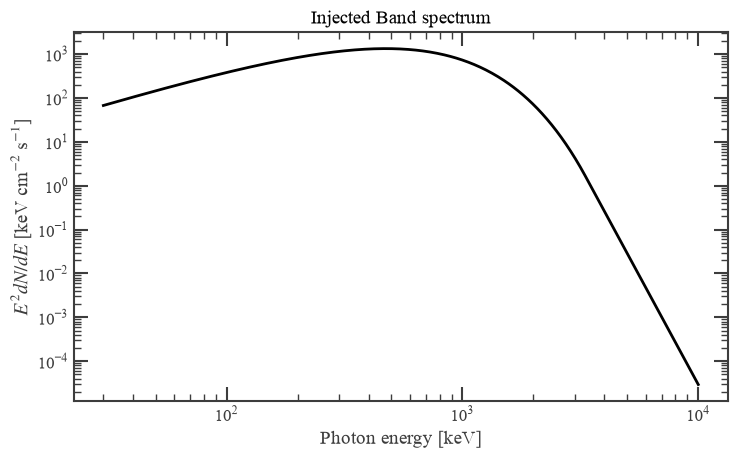

In [3]:
spectrum = Band()
spectrum.K.unit = 1/(u.keV*u.cm**2*u.s)
spectrum.xp.unit = u.keV
spectrum.piv.unit = u.keV
spectrum.piv.value = pivot_keV

# Important warning-free order: first move beta, then tighten its bounds.
spectrum.beta.value = -3.0
for name, (lower, upper) in fit_bounds.items():
    parameter = getattr(spectrum, name)
    parameter.min_value = lower
    parameter.max_value = upper

for name, value in injected_band.items():
    getattr(spectrum, name).value = value

source = PointSource(
    source_name,
    l=source_coord.galactic.l.deg,
    b=source_coord.galactic.b.deg,
    spectral_shape=spectrum,
)
model = Model(source)

energy_plot = np.geomspace(30.0, 10000.0, 500)
fig, ax = plt.subplots(figsize=(7.6, 4.8))
ax.plot(energy_plot, energy_plot**2*np.asarray(spectrum(energy_plot), float), color='black', lw=2)
ax.set(xscale='log', yscale='log', xlabel='Photon energy [keV]',
       ylabel=r'$E^2 dN/dE$ [keV cm$^{-2}$ s$^{-1}$]', title='Injected Band spectrum')
style_axes(ax)
fig.tight_layout()
plt.show()

#### 4. Build the COSIpy CC response and generate the source fake

Open the one-second background once, but use **only its axes** at this stage.
Selecting `axes[['Em', 'Phi', 'PsiChi']]` retains the bin edges, units and HEALPix
coordinate metadata without summing the full background history. A zero-filled
histogram defines the observation space; none of the background counts are used
as source counts. The shape is `(10, 36, 768)` for these inputs.

COSIpy combines the full CC response with source position and selected attitude/
livetime, then folds the injected Band spectrum into `cc_expected_source_values`
(mean counts per CDS bin). An independent seeded Poisson draw gives
`cc_source_fake_values`. Both stay in memory; no CC source HDF5 is written.

In [4]:
# Select attitude/livetime over the ON interval; the response uses the changing source direction.
sc_history = SpacecraftHistory.open(orientation_path, tstart, tstop).select_interval(tstart, tstop)
cc_livetime_s = float(sc_history.cumulative_livetime().to_value(u.s))

# Read the background once: its measurement axes also define the source/data bins.
# Selecting axes copies no counts and does not sum over the full time history.
cc_all_background = Histogram.open(cc_time_resolved_background_path)
cc_axes = cc_all_background.axes[['Em', 'Phi', 'PsiChi']]
print('CC measured-bin shape (Em, Phi, PsiChi):', cc_axes.shape)
cc_zero_histogram = Histogram(
    cc_axes,
    contents=np.zeros(cc_axes.shape, dtype=float),
    sparse=False,
)
# COSIpy holds a reference to this histogram; Section 5 fills it with the generated ON counts.
cc_data = EmCDSBinnedData(cc_zero_histogram)

# Adapt the full detector response to these observed bins.
cc_full_response = FullDetectorResponse.open(cc_response_path)
cc_instrument_response = BinnedInstrumentResponse(cc_full_response, cc_data)
# Fold the source position through the attitude history to obtain its exposure-weighted response.
cc_point_response = BinnedThreeMLPointSourceResponse(
    data=cc_data,
    instrument_response=cc_instrument_response,
    sc_history=sc_history,
    energy_axis=cc_full_response.axes['Ei'],
    polarization_axis=(cc_full_response.axes['Pol'] if 'Pol' in cc_full_response.axes.labels else None),
    nside=2*cc_data.axes['PsiChi'].nside,
)
# Connect the spectral model to the point-source response; expectation() returns counts, not flux.
cc_folding = BinnedThreeMLModelFolding(data=cc_data, point_source_response=cc_point_response)
cc_folding.set_model(model)

# Compute the injected source mean in every (Em, Phi, PsiChi) bin.
cc_source_expectation = cc_folding.expectation()
cc_expected_source_values = np.asarray(
    getattr(cc_source_expectation.to_dense(copy=False).contents, 'value',
            cc_source_expectation.to_dense(copy=False).contents),
    dtype=float,
)
# Draw an independent integer Poisson count in each bin using a reproducible source seed.
cc_source_rng = np.random.default_rng(cc_poisson_seed)
cc_source_fake_values = cc_source_rng.poisson(np.clip(cc_expected_source_values, 0.0, None))
# Keep the mean and sampled counts in memory; Section 5 adds the background.
print(f'Expected / simulated CC source counts: {cc_expected_source_values.sum():.2f} / {cc_source_fake_values.sum():.0f}')

CC measured-bin shape (Em, Phi, PsiChi): (10, 36, 768)


Expected / simulated CC source counts: 20865.08 / 20857


#### 5. Generate the CC background fake and fit template

The **OFF template** is the sum of two 100 s intervals bracketing the 40 s ON
interval; no ON counts enter it. `cc_fit_background_template` stores that histogram.
For fake generation, `cc_expected_background_values = OFF counts * 40 / 200`
is the estimated ON mean. A separate Poisson draw with seed `cc_poisson_seed + 1`
produces `cc_background_fake_values`. Add it to `cc_source_fake_values` and place
the total in `cc_data.data`, which is the synthetic observation to be fitted.

The random ON background realization is **not** used as the fit's background
template. Instead, `FreeNormBinnedBackground` normalizes the OFF histogram to a
unit-sum shape and multiplies it by a free background rate [Hz] and ON livetime.
We treat the OFF-derived shape as fixed, not as a separate Poisson OFF likelihood;
finite-template and time-variation systematics are outside this simple example.
ON/OFF duration scaling assumes a comparable background rate/livetime fraction
over these intervals. All these quantities remain in memory, not separate HDF5 files.

In [5]:
def select_time_interval(histogram, start_unix, stop_unix):
    """Select exact one-second Time bins from a HistPy histogram."""
    edges = np.asarray(histogram.axes['Time'].edges.to_value(u.s), dtype=float)
    # Convert exact time boundaries to half-open bin indices [first, last).
    first = int(np.searchsorted(edges, start_unix, side='left'))
    last = int(np.searchsorted(edges, stop_unix, side='left'))
    if first >= len(edges) or last >= len(edges):
        raise ValueError('Requested interval lies outside the background Time axis')
    if not np.allclose([edges[first], edges[last]], [start_unix, stop_unix], atol=1.0e-4, rtol=0):
        raise ValueError('CC background start/stop must coincide with its 1 s Time edges')
    return histogram.slice[{'Time': slice(first, last)}]

# Reuse the background opened in Section 4; extract OFF bins, excluding the ON interval.
cc_background_before = select_time_interval(
    cc_all_background, tstart.unix-cc_off_before_s, tstart.unix,
).project('Em', 'Phi', 'PsiChi')
cc_background_after = select_time_interval(
    cc_all_background, tstop.unix, tstop.unix+cc_off_after_s,
).project('Em', 'Phi', 'PsiChi')
# Their sum provides the background shape independently of the fake ON counts.
cc_fit_background_template = cc_background_before + cc_background_after

cc_off_exposure_s = cc_off_before_s + cc_off_after_s
cc_template_values = np.asarray(
    getattr(cc_fit_background_template.to_dense(copy=False).contents, 'value',
            cc_fit_background_template.to_dense(copy=False).contents),
    dtype=float,
)
# Scale the OFF counts by ON/OFF duration to obtain the expected background in the ON interval.
cc_expected_background_values = cc_template_values*exposure_s/cc_off_exposure_s
# Use a separate Poisson seed from the source, then add the two independent realizations.
cc_background_rng = np.random.default_rng(cc_poisson_seed + 1)
cc_background_fake_values = cc_background_rng.poisson(np.clip(cc_expected_background_values, 0.0, None))
# Populate the same data object that the CC response and likelihood reference.
cc_data.data.contents[...] = cc_source_fake_values + cc_background_fake_values

cc_background_template = cc_fit_background_template.to_dense()
# Keep empty template bins infinitesimally positive to avoid log(0); this adds negligible counts.
cc_background_template += sys.float_info.min
# COSIpy normalizes the OFF shape internally; bkg_norm is a fitted total count rate [Hz].
cc_background_model = FreeNormBinnedBackground(cc_background_template, sc_history=sc_history, copy=False)
# The Poisson mean is source expectation + background expectation in every CC bin.
cc_poisson = PoissonLikelihood(cc_data, cc_folding, cc_background_model)
# Expose the COSIpy likelihood and its background-rate parameter to threeML.
cc_plugin = ThreeMLPluginInterface('cosi_cc', cc_poisson, cc_folding, cc_background_model)

# Initialize the free background rate from the generated ON background, divided by livetime.
cc_background_start_hz = float(cc_background_fake_values.sum())/cc_livetime_s
cc_plugin.bkg_parameter['bkg_norm'] = Parameter(
    'bkg_norm', cc_background_start_hz, unit=u.Hz,
    min_value=cc_background_bounds_hz[0], max_value=cc_background_bounds_hz[1], delta=1.0e-3,
)

print(f'CC livetime: {cc_livetime_s:.3f} s')
print(f'Expected / simulated CC background counts: {cc_expected_background_values.sum():.2f} / {cc_background_fake_values.sum():.0f}')
print('CC total ON counts:', int(cc_source_fake_values.sum() + cc_background_fake_values.sum()))
print('CC products remain in memory; no intermediate CC HDF5 files are written.')

CC livetime: 40.000 s
Expected / simulated CC background counts: 231.60 / 222
CC total ON counts: 21079
CC products remain in memory; no intermediate CC HDF5 files are written.


#### 6. Prepare BTO Response: From the Simulated deposit response to the OGIP ARF and RMF

Overview of the BTO response construction is as follows:
Megalib/Cosima simulation counts:  
    ↓ normalization by incident photons and simulation start area  
HDF5 area_matrix_cm2(Etrue, Edeposit)  
    ↓ direction interpolation and observation-time averaging  
one observation-specific deposit-area matrix A(Etrue, Edeposit)  
    ↓ DEE: resolution + gain + threshold + saturation  
Response Matrix RSP(Etrue, channel) = ARF * RMF
    ↓ row sum and normalization  
ARF(Etrue) and RMF(Etrue, channel)  
    ↓  
OGIP ARF / RMF / RSP  

------ 

The BTO HDF5 file does not contain a ready-to-fit ARF/RMF. It stores an effective-area matrix in true photon energy and deposited energy in the units of cm²:

$$
A^{\rm H5}_{dqi k}
=
\texttt{area\_matrix\_cm2[detector }d,\texttt{ direction }q,
                         \texttt{ true-energy }i,\texttt{ deposit-energy }k].
$$

The HDF5 also contains `response/arf_cm2`, which is simply the deposit-axis sum
of this unsmeared matrix for each simulated detector and direction. It is useful
as a simulation diagnostic, but it is not the final OGIP ARF used in the fit.

##### Step 1: select the detector and observation direction
`get_bto_response` first selects BTO1 or BTO2. For each spacecraft direction
sample in the selected observation interval, it interpolates the four nearest
simulated HEALPix directions using inverse-angular-distance-squared weights.
The interpolated matrices are then averaged using the spacecraft-history
time/livetime weights.

The result is one observation-specific deposit response,

$$
A_{ik}
=
\texttt{unsmeared\_area\_matrix\_cm2[i,k]},
$$

for the requested detector, celestial source position, orientation file, and
time interval.

Its deposit-axis sum,

$$
A^{\rm deposit}_i
=
\sum_k A_{ik},
$$

is returned as `unsmeared_arf_cm2`. This blue curve represents all stored
Geant4 deposits before the detector detector effects model, including both full-energy
and partial-energy deposits.

##### Step 2: apply the detector effects model
The Detector Effects Engine (DEE) converts deposited energy into recorded
measurement channels.
For this tutorial, the DEE uses the following configurable placeholder model:
- 4096 measured channels;
- linear gain of 0.8125 keV/channel;
- zero gain offset and zero quadratic gain term;
- a 30 keV measured-energy threshold;
- a 3000 keV saturation limit;
- a Gaussian resolution with constant scale: $\mathrm{FWHM}(E)/E = 65/662$.

These values are analysis placeholders. It is not the full empirical resolution fit and should be replaced with a measured flight-detector calibration in the future.
The current DEE does not model waveform formation, trigger timing, pile-up, dead time, gain drift, or detector-to-detector calibration differences.

For a deposit-energy bin \(k\), the current implementation places the Gaussian
mean at the center $E^{\rm dep}_k$ of that deposit bin and evaluates

$$
\sigma_k
=
\sqrt{
a_0+a_1E^{\rm dep}_k+a_2(E^{\rm dep}_k)^2
}.
$$
where \(\Phi\) is the standard-normal cumulative distribution function.

The lower channel edge is clipped at the 30 keV threshold and the upper edge is
clipped at the 3000 keV saturation limit. Gaussian probability below the
threshold, above saturation, or outside the available channel range is discarded.
It is not renormalized back into the response.

##### Step 3: Construct the response matrix RSP
The deposit response and the deposit-to-channel probability matrix are combined as
$$
R_{ij}
=
\sum_k A_{ik} P_{kj}.
$$
In the Python result object, this matrix is:  
response.rsp_cm2[i, j] with shape [n_true_energy, n_measured_channel] and units cm². 
This is the matrix used when a photon spectrum is folded into expected channel counts.

##### Step 4: Generate OGIP ARF and RMF response files from the recorded-channel response

`write_ogip_response` writes three equivalent representations:
- .arf: the recorded effective area $\mathrm{ARF}_i$
- .rmf: the conditional redistribution probability  $\mathrm{RMF}_{ij}$;
- .rsp: the combined response matrix $\mathrm{R}_{ij}$. = ARF * RMF
  
In this tutorial, `simulate_bto_spectrum` directly folds the photon spectrum
through  `response.rsp_cm2`. The threeML fit uses the mathematically equivalent standalone OGIP ARF and RMF files.  

The additional 30–2500 keV setting in OGIPLike is a fit-time selection of
measured channels. It is applied after the full response has been constructed
and is distinct from the 30 keV threshold and 3000 keV saturation settings in
the DEE.  

Once an OGIP response has been generated, load_bto_response reads that
already-smeared recorded response. It does not apply the Gaussian resolution,
gain, threshold, or saturation a second time. To change any of those settings,
a new response must be generated from bto_response_order2.h5.

** While there are no practical issues, the statistics used to generate the response are somewhat limited, resulting in some fluctuations in the plot.

BTO1
BTOCalibration(n_channels=4096, gain_quadratic_ch_per_keV2=0.0, gain_slope_ch_per_keV=1.2307692307692308, gain_offset_ch=0.0, lower_threshold_keV=30.0, upper_saturation_keV=3000.0, name='BTO science placeholder 4096ch 0.8125keV/ch', provenance='Configurable analysis placeholder; not measured flight BTO calibration')
BTOResolution(a0_keV2=0.0, a1_keV=0.0, a2=0.0017385824300377962, name='Prototype resolution (approximate constant fraction)', provenance='Approximation normalized to the reported 65 keV FWHM at 662 keV; Nagasawa et al. 2025 prototype; not full-fit coefficients or flight calibration')
BTO1 (100, 4096) orientation samples = 42


BTO2
BTOCalibration(n_channels=4096, gain_quadratic_ch_per_keV2=0.0, gain_slope_ch_per_keV=1.2307692307692308, gain_offset_ch=0.0, lower_threshold_keV=30.0, upper_saturation_keV=3000.0, name='BTO science placeholder 4096ch 0.8125keV/ch', provenance='Configurable analysis placeholder; not measured flight BTO calibration')
BTOResolution(a0_keV2=0.0, a1_keV=0.0, a2=0.0017385824300377962, name='Prototype resolution (approximate constant fraction)', provenance='Approximation normalized to the reported 65 keV FWHM at 662 keV; Nagasawa et al. 2025 prototype; not full-fit coefficients or flight calibration')
BTO2 (100, 4096) orientation samples = 42


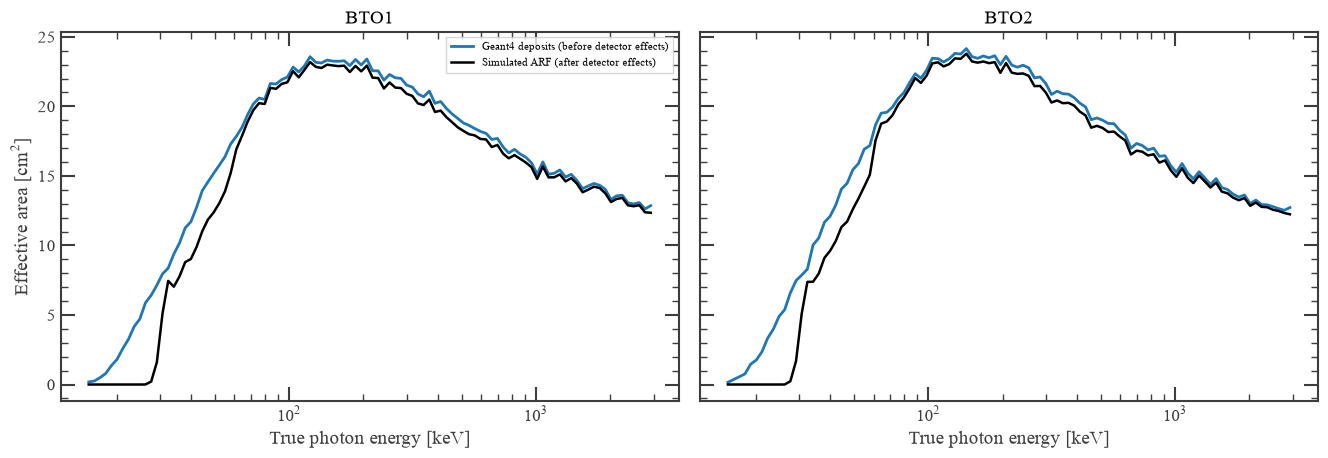

In [6]:
# One response per named detector; source direction and observation interval are shared.
bto_responses = {}
for detector_name in bto_ids:
    # Rotate the celestial source through the attitude history and average the interpolated responses.
    response = get_bto_response(
        bto_response_h5_path,
        detector_name,
        orientation_file=orientation_path,
        source_coord=source_coord,
        tstart=tstart,
        tstop=tstop,
        calibration=bto_calibration, resolution=bto_resolution,
        earth_occultation=False,
        write_ogip=False,
    )
    # Write the recorded ARF and conditional RMF; their product is the area-valued RSP.
    write_ogip_response(response, output_path/detector_name.lower(), overwrite=True)
    bto_responses[detector_name] = response
    print(detector_name, response.calibration, response.resolution, sep='\n')
    print(detector_name, response.rsp_cm2.shape, 'orientation samples =', response.metadata['orientation_samples'])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)
for ax, detector_name in zip(axes, bto_ids):
    response = bto_responses[detector_name]
    etrue = np.sqrt(response.photon_energy_edges_keV[:-1]*response.photon_energy_edges_keV[1:])
    # Blue: sum over ALL stored deposit bins, before smearing or measured-energy cuts.
    ax.plot(etrue, response.unsmeared_arf_cm2, color='tab:blue', lw=2, label='Geant4 deposits (before detector effects)')
    ax.plot(etrue, response.arf_cm2, color='black', lw=1.8, label='Simulated ARF (after detector effects)')
    # This floor changes only the logarithmic plot limits, never the response arrays.
    displayed = np.concatenate((response.unsmeared_arf_cm2, response.photopeak_arf_cm2, response.arf_cm2))
    ax.set(xscale='log', yscale='linear', xlabel='True photon energy [keV]', title=detector_name)
    style_axes(ax)
axes[0].set_ylabel(r'Effective area [cm$^2$]')
axes[0].legend(frameon=True)
fig.tight_layout()
fig.savefig(output_path/'bto1_bto2_response_components.png', dpi=180)
plt.show()

#### 7. Make independent BTO1 and BTO2 backgrounds and fake spectra

The 10--3000 keV template is regridded separately onto each response using its
embedded energy boundaries. Each detector receives an independent Poisson
realization. The fit selects **30--2500 keV**, fully covered by this template.
For readability, the quick-look count spectra are summed in groups of 16 native
ADC channels. The template is a weighted/smoothed mean, not raw Poisson counts;
the generated OGIP BAK uses a Poisson-equivalent uncertainty for this demonstration.

16:49:42 INFO      Auto-probed noise models:                                                    ]8;id=2579158;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=2579159;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

INFO      - observation: poisson                                                       ]8;id=2579167;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=2579168;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

INFO      - background: gaussian                                                       ]8;id=2579176;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=2579177;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

INFO      Range 30.0-2500.0 translates to channels 36-3076                            ]8;id=2579185;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=2579186;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

16:49:44 INFO      Now using 75 bins                                                           ]8;id=2579194;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=2579195;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1706\1706]8;;\

...

INFO      - observation: poisson                                                       ]8;id=2579210;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=2579211;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

INFO      - background: gaussian                                                       ]8;id=2579218;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=2579219;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

INFO      Range 30.0-2500.0 translates to channels 36-3076                            ]8;id=2579226;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=2579227;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

INFO      Now using 75 bins                                                           ]8;id=2579234;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=2579235;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1706\1706]8;;\

BTO2 source/background/simulated = 8590.084059637893 1663.2562809136818 10335 grouped fit bins = 75


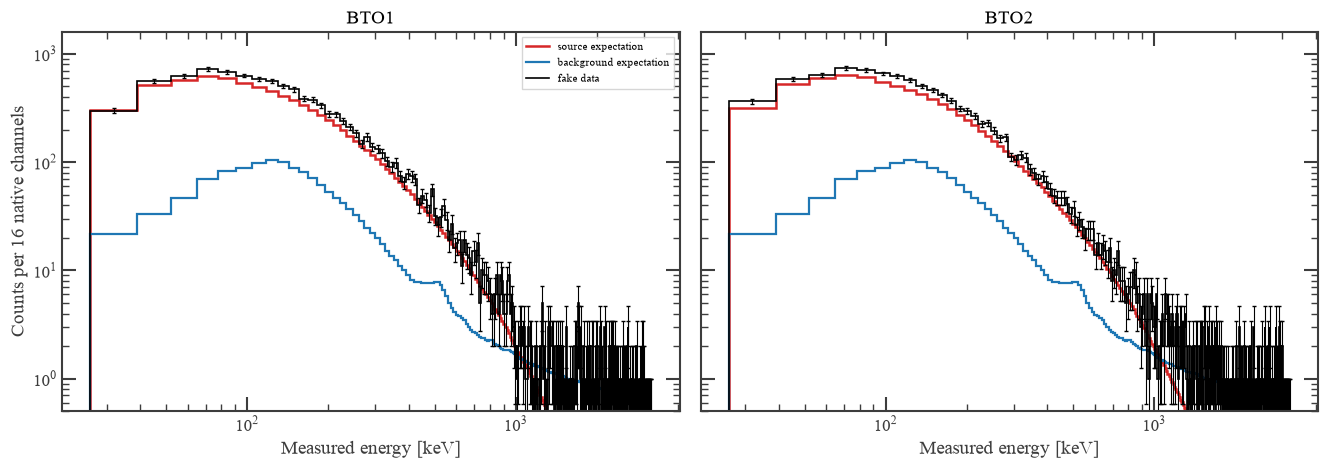

In [7]:
# Restore the injection before folding fake BTO data.
for name, value in injected_band.items():
    getattr(spectrum, name).value = value

bto_backgrounds = {}
bto_fakes = {}
bto_plugins = {}

for detector_name in bto_ids:
    response = bto_responses[detector_name]
    # Regrid the constant reference background onto this detector's measured channels (counts/s/channel).
    background = get_bto_background(
        response,
        background_template=bto_background_template_path,
    )
    # Encode that background in OGIP format so threeML can use the same grid and exposure.
    write_ogip_background(
        background, response, output_path/f'{detector_name.lower()}_background.bak',
        exposure_s=exposure_s, overwrite=True,
    )
    # Integrate the injected photon model over true-energy bins, fold with RSP, add background, draw counts.
    fake = simulate_bto_spectrum(
        response, spectrum, exposure_s,
        background=background, poisson=True, random_seed=bto_poisson_seeds[detector_name],
        output_pha=output_path/f'{detector_name.lower()}_fake.pha', overwrite=True,
    )
    # Fit with the recorded ARF times the conditional RMF, including Compton-continuum redistribution.
    plugin = OGIPLike(
        detector_name.lower(), observation=fake.pha_path, background=background.path,
        response=str(response.rmf_path), arf_file=str(response.arf_path), verbose=False,
    )
    # Select measured energies for fitting; this is separate from the response threshold and saturation.
    plugin.set_active_measurements(f'{bto_active_range_keV[0]}-{bto_active_range_keV[1]}')
    # Merge channels to reach the requested background counts per fit bin.
    plugin.rebin_on_background(bto_background_grouping)
    # Both BTO plugins share the same astrophysical source parameters as CC.
    plugin.assign_to_source(source_name)
    bto_backgrounds[detector_name] = background
    bto_fakes[detector_name] = fake
    bto_plugins[detector_name] = plugin
    print(detector_name, 'source/background/simulated =',
          fake.expected_source_counts.sum(), fake.expected_background_counts.sum(), fake.simulated_counts.sum(),
          'grouped fit bins =', len(plugin.current_observed_counts))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.9), sharey=True)
# Display-only grouping: this does not alter the independently grouped likelihood bins.
ql_group = 16
for ax, detector_name in zip(axes, bto_ids):
    response = bto_responses[detector_name]
    fake = bto_fakes[detector_name]
    n_native = (len(fake.simulated_counts)//ql_group)*ql_group
    edges = response.measured_energy_edges_keV[:n_native+1:ql_group]
    source_counts = fake.expected_source_counts[:n_native].reshape(-1, ql_group).sum(axis=1)
    background_counts = fake.expected_background_counts[:n_native].reshape(-1, ql_group).sum(axis=1)
    observed_counts = fake.simulated_counts[:n_native].reshape(-1, ql_group).sum(axis=1)
    centers = np.sqrt(np.clip(edges[:-1], 1.0e-6, None)*np.clip(edges[1:], 1.0e-6, None))
    use = (edges[:-1] >= 20.0) & (edges[1:] <= 3200.0)
    first, last = np.flatnonzero(use)[[0, -1]]
    sl = slice(first, last+1)
    edge_slice = edges[first:last+2]
    ax.stairs(source_counts[sl], edge_slice, color='tab:red', lw=1.8, label='source expectation')
    ax.stairs(background_counts[sl], edge_slice, color='tab:blue', lw=1.6, label='background expectation')
    ax.stairs(observed_counts[sl], edge_slice, color='black', lw=1.2, label='fake data')
    ax.errorbar(centers[sl], observed_counts[sl], yerr=np.sqrt(np.clip(observed_counts[sl], 1.0, None)),
                fmt='none', color='black', elinewidth=0.8, capsize=1.5)
    ax.set(xscale='log', yscale='log', ylim=(0.5, None), xlabel='Measured energy [keV]', title=detector_name)
    style_axes(ax)
axes[0].set_ylabel(f'Counts per {ql_group} native channels')
axes[0].legend(frameon=True)
fig.tight_layout()
fig.savefig(output_path/'bto1_bto2_fake_spectra.png', dpi=180)
plt.show()

#### 8. Minimal helpers for fit-state and profile likelihood

These small helpers for restoring parameter values and when profiling the same likelihood algorithm over several parameters. Profile results stay in memory as `DataFrame` objects;

In [8]:
band_parameter_names = ('K', 'alpha', 'xp', 'beta')

# Set the Band parameters from a dictionary of values, or read them into a dictionary.
def set_band(values):
    for name in band_parameter_names:
        getattr(spectrum, name).value = float(values[name])

def get_band():
    return {name: float(getattr(spectrum, name).value) for name in band_parameter_names}

def covariance_scale(covariance, short_name, parameter):
    # Use covariance errors only to choose a scan range, not as the reported profile interval.
    matches = [index for index in covariance.index if str(index).split('.')[-1] == short_name]
    if len(matches) == 1:
        row = covariance.loc[matches[0]]
        values = [abs(float(row[column])) for column in ('negative_error', 'positive_error') if column in row]
        values = [value for value in values if np.isfinite(value) and value > 0]
        if values:
            return max(values)
    lower = float(parameter.min_value) if parameter.min_value is not None else float(parameter.value)-1.0
    upper = float(parameter.max_value) if parameter.max_value is not None else float(parameter.value)+1.0
    return max(0.05*(upper-lower), 1.0e-6)

def profile_likelihood(label, likelihood, parameter_map, best_values, covariance, minimum_nll):
    """Fix one parameter on a grid and re-optimize every other free parameter."""
    original_free = {name: bool(parameter.free) for name, parameter in parameter_map.items()}
    rows = []
    for name, parameter in parameter_map.items():
        center = float(best_values[name])
        if name == 'beta':
            # The high-energy tail is often one-sided. Scan its entire declared
            # interval so an unconstrained lower side is reported at -20 rather
            # than disappearing as a NaN/error-bar point.
            lower = float(parameter.min_value)
            upper = float(parameter.max_value)
            grid = np.linspace(lower, upper, beta_profile_points)
        else:
            sigma = covariance_scale(covariance, name, parameter)
            lower = center-profile_half_width_sigma*sigma
            upper = center+profile_half_width_sigma*sigma
            if parameter.min_value is not None:
                lower = max(lower, float(parameter.min_value))
            if parameter.max_value is not None:
                upper = min(upper, float(parameter.max_value))
            grid = np.linspace(lower, upper, profile_points)
        grid = np.unique(np.concatenate((grid, [center])))
        # Scan outwards from the best fit; warm-start nuisance parameters along each side.
        branches = (np.sort(grid[grid >= center]), np.sort(grid[grid < center])[::-1])
        for branch in branches:
            for restore_name, restore_parameter in parameter_map.items():
                restore_parameter.value = float(best_values[restore_name])
                restore_parameter.free = original_free[restore_name]
            # Hold this parameter fixed while all originally free nuisance parameters are refitted.
            parameter.free = False
            for fixed_value in branch:
                parameter.value = float(fixed_value)
                try:
                    _, statistic = likelihood.fit(quiet=True, compute_covariance=False)
                    nll = float(statistic.loc['total', '-log(likelihood)'])
                    # Convert NLL into the likelihood-ratio statistic used for 68%/95% crossings.
                    delta = max(0.0, 2.0*(nll-minimum_nll))
                    status = 'ok'
                except Exception as error:
                    nll, delta = np.nan, np.nan
                    status = f'{type(error).__name__}: {error}'
                # Keep status and likelihood values in memory so failures are inspectable even with warnings muted.
                rows.append({'dataset': label, 'parameter': name, 'fixed_value': float(fixed_value),
                             'twice_delta_nll': delta, 'minus_log_likelihood': nll, 'status': status})
        for restore_name, restore_parameter in parameter_map.items():
            restore_parameter.value = float(best_values[restore_name])
            restore_parameter.free = original_free[restore_name]
    return pd.DataFrame(rows).drop_duplicates(['dataset', 'parameter', 'fixed_value'])

def profile_limit(profile, parameter_name, center, threshold, side, parameter):
    """Return (limit, bound_limited) for the connected interval around center."""
    selected = profile[(profile.parameter == parameter_name) & np.isfinite(profile.twice_delta_nll)]
    selected = selected.sort_values('fixed_value')
    x = selected.fixed_value.to_numpy(float)
    y = selected.twice_delta_nll.to_numpy(float)
    mask = x < center if side == 'lower' else x > center
    xs, ys = x[mask], y[mask]
    order = np.argsort(np.abs(xs-center))
    previous_x, previous_y = center, 0.0
    for current_x, current_y in zip(xs[order], ys[order]):
        if current_y >= threshold and previous_y < threshold:
            fraction = (threshold-previous_y)/(current_y-previous_y)
            return previous_x + fraction*(current_x-previous_x), False
        previous_x, previous_y = current_x, current_y

    # Reaching a configured bound without a crossing is a one-sided/bound-limited result.
    physical_bound = parameter.min_value if side == 'lower' else parameter.max_value
    if physical_bound is not None:
        physical_bound = float(physical_bound)
        if not len(xs) and np.isclose(center, physical_bound):
            return physical_bound, True
        if len(xs) and np.isclose(xs[order][-1], physical_bound) and ys[order][-1] < threshold:
            return physical_bound, True
    return np.nan, False

#### 9. Fit and profile the CC-only dataset

Based on the fake spectrum and the CC-only response, the CC-only fit is performed first. The Band parameters and CC background normalization are reset to their stated starting values.

In [9]:
# Reset optimizer starting values; the injected values only generated the data.
set_band(fit_start)
for name in band_parameter_names:
    getattr(spectrum, name).free = True
cc_plugin.bkg_parameter['bkg_norm'].value = cc_background_start_hz
cc_plugin.bkg_parameter['bkg_norm'].free = True
cc_folding.set_model(model)

# CC-only fit: maximize this one plugin while fitting both spectrum and CC background rate.
cc_likelihood = JointLikelihood(model, DataList(cc_plugin), verbose=False)
cc_likelihood.set_minimizer(minimizer_name)
cc_covariance, cc_statistic = cc_likelihood.fit(quiet=True, compute_covariance=True)
# Restore and copy the optimum before the profile scan temporarily changes parameter values.
cc_likelihood.restore_best_fit()

cc_best_band = get_band()
cc_best_background_hz = float(cc_plugin.bkg_parameter['bkg_norm'].value)
cc_best_values = {**cc_best_band, 'bkg_norm': cc_best_background_hz}
# Profile each spectral parameter and the CC background rate, re-optimizing the others.
cc_profile_parameters = {name: getattr(spectrum, name) for name in band_parameter_names}
cc_profile_parameters['bkg_norm'] = cc_plugin.bkg_parameter['bkg_norm']
cc_minimum_nll = float(cc_statistic.loc['total', '-log(likelihood)'])
cc_profile = profile_likelihood(
    'CC only', cc_likelihood, cc_profile_parameters, cc_best_values, cc_covariance, cc_minimum_nll,
)
print('CC-only best fit:', cc_best_values)
print('CC-only profile status:', cc_profile.status.value_counts().to_dict())

16:49:45 INFO      set the minimizer to minuit                                             ]8;id=2579244;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=2579245;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

INFO      set the minimizer to MINUIT                                             ]8;id=2579253;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=2579254;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1034\1034]8;;\

CC-only best fit: {'K': 0.030486600602712736, 'alpha': -0.3692359594772321, 'xp': 465.1274673403182, 'beta': -16.923681898042535, 'bkg_norm': 5.505322291563841}
CC-only profile status: {'ok': 86}


#### 10. Fit CC + BTO1 + BTO2 (free cross-normalization)

The same source model is shared by all three plugins. Both BTO effective-area factors $C_{\rm BTO1}$ and $C_{\rm BTO2}$ are fitted independently over 0.5--1.5, with CC as the reference (factor 1). The two BTO backgrounds remain independent of these effective-area factors.

In [10]:
# Set BTO-to-CC effective-area factors; CC remains the normalization reference.
for plugin in bto_plugins.values():
    plugin.use_effective_area_correction(*cross_norm_bounds)
    nuisance = plugin.nuisance_parameters[f'cons_{plugin.name}']
    nuisance.value = cross_norm_start
    nuisance.free = True

# Restart the shared source spectrum and CC background from the same initial conditions.
set_band(fit_start)
for name in band_parameter_names:
    getattr(spectrum, name).free = True
cc_plugin.bkg_parameter['bkg_norm'].value = cc_background_start_hz
cc_plugin.bkg_parameter['bkg_norm'].free = True
cc_folding.set_model(model)

# threeML sums the CC, BTO1 and BTO2 log-likelihoods for a single common source model.
joint_plugins = [cc_plugin, bto_plugins['BTO1'], bto_plugins['BTO2']]
joint_likelihood = JointLikelihood(model, DataList(*joint_plugins), verbose=False)
joint_likelihood.set_minimizer(minimizer_name)
joint_covariance, joint_statistic = joint_likelihood.fit(quiet=True, compute_covariance=True)
# Save the optimum separately so plotting and profiling do not overwrite the fit result.
joint_likelihood.restore_best_fit()

joint_best_band = get_band()
joint_best_background_hz = float(cc_plugin.bkg_parameter['bkg_norm'].value)
joint_best_values = {**joint_best_band, 'bkg_norm': joint_best_background_hz}
# Include every free nuisance parameter when profiling the joint likelihood.
joint_profile_parameters = {name: getattr(spectrum, name) for name in band_parameter_names}
joint_profile_parameters['bkg_norm'] = cc_plugin.bkg_parameter['bkg_norm']
joint_cross_norms = {}
for detector_name, plugin in bto_plugins.items():
    short_name = f'C_{detector_name}'
    parameter = plugin.nuisance_parameters[f'cons_{plugin.name}']
    joint_cross_norms[detector_name] = float(parameter.value)
    joint_best_values[short_name] = float(parameter.value)
    joint_profile_parameters[short_name] = parameter
joint_minimum_nll = float(joint_statistic.loc['total', '-log(likelihood)'])
joint_profile = profile_likelihood(
    r'CC + BTO1 + BTO2 ($C_{\rm BTO1},C_{\rm BTO2}$ free)', joint_likelihood, joint_profile_parameters,
    joint_best_values, joint_covariance, joint_minimum_nll,
)
print('Joint best Band:', joint_best_band)
print('Joint cross-normalizations:', joint_cross_norms)
print('Joint profile status:', joint_profile.status.value_counts().to_dict())

16:50:31 INFO      bto1 is using effective area correction (between 0.5 and 1.5)               ]8;id=2579262;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=2579263;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

INFO      bto2 is using effective area correction (between 0.5 and 1.5)               ]8;id=2579270;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=2579271;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

INFO      set the minimizer to minuit                                             ]8;id=2579278;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=2579279;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

INFO      set the minimizer to MINUIT                                             ]8;id=2579286;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=2579287;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1034\1034]8;;\

Joint best Band: {'K': 0.03056743782915769, 'alpha': -0.3634837376499522, 'xp': 466.6724385819234, 'beta': -16.890373253214015}
Joint cross-normalizations: {'BTO1': 0.9944811083983514, 'BTO2': 1.0019770519678008}
Joint profile status: {'ok': 116}


#### 11. Parameter and profile comparison

Parameter plots use thin 95% and thick 68% horizontal intervals, with triangles for bounds reached before a likelihood crossing. 

,dataset,parameter,best_fit,lower_68,upper_68,lower_95,upper_95,lower_68_bound_limited,upper_68_bound_limited,lower_95_bound_limited,upper_95_bound_limited
0,CC only,K,0.030487,0.028779,0.032325,0.027157,0.034348,False,False,False,False
1,Joint,K,0.030567,0.029551,0.031623,0.028577,0.032718,False,False,False,False
2,CC only,alpha,-0.369236,-0.414464,-0.323636,-0.458849,-0.277988,False,False,False,False
3,Joint,alpha,-0.363484,-0.384793,-0.342032,-0.406006,-0.320412,False,False,False,False
4,CC only,xp,465.127467,460.570026,469.750164,456.129305,474.405537,False,False,False,False
5,Joint,xp,466.672439,462.520705,470.897846,458.417479,475.239203,False,False,False,False
6,CC only,beta,-16.923682,-20.000000,-7.429150,-20.000000,-5.947115,True,False,True,False
7,Joint,beta,-16.890373,-20.000000,-7.443961,-20.000000,-5.978847,True,False,True,False
8,CC only,bkg_norm,5.505322,5.113290,5.915068,4.732740,6.349592,False,False,False,False
9,Joint,bkg_norm,5.503438,5.101007,5.920746,4.718796,6.350772,False,False,False,False


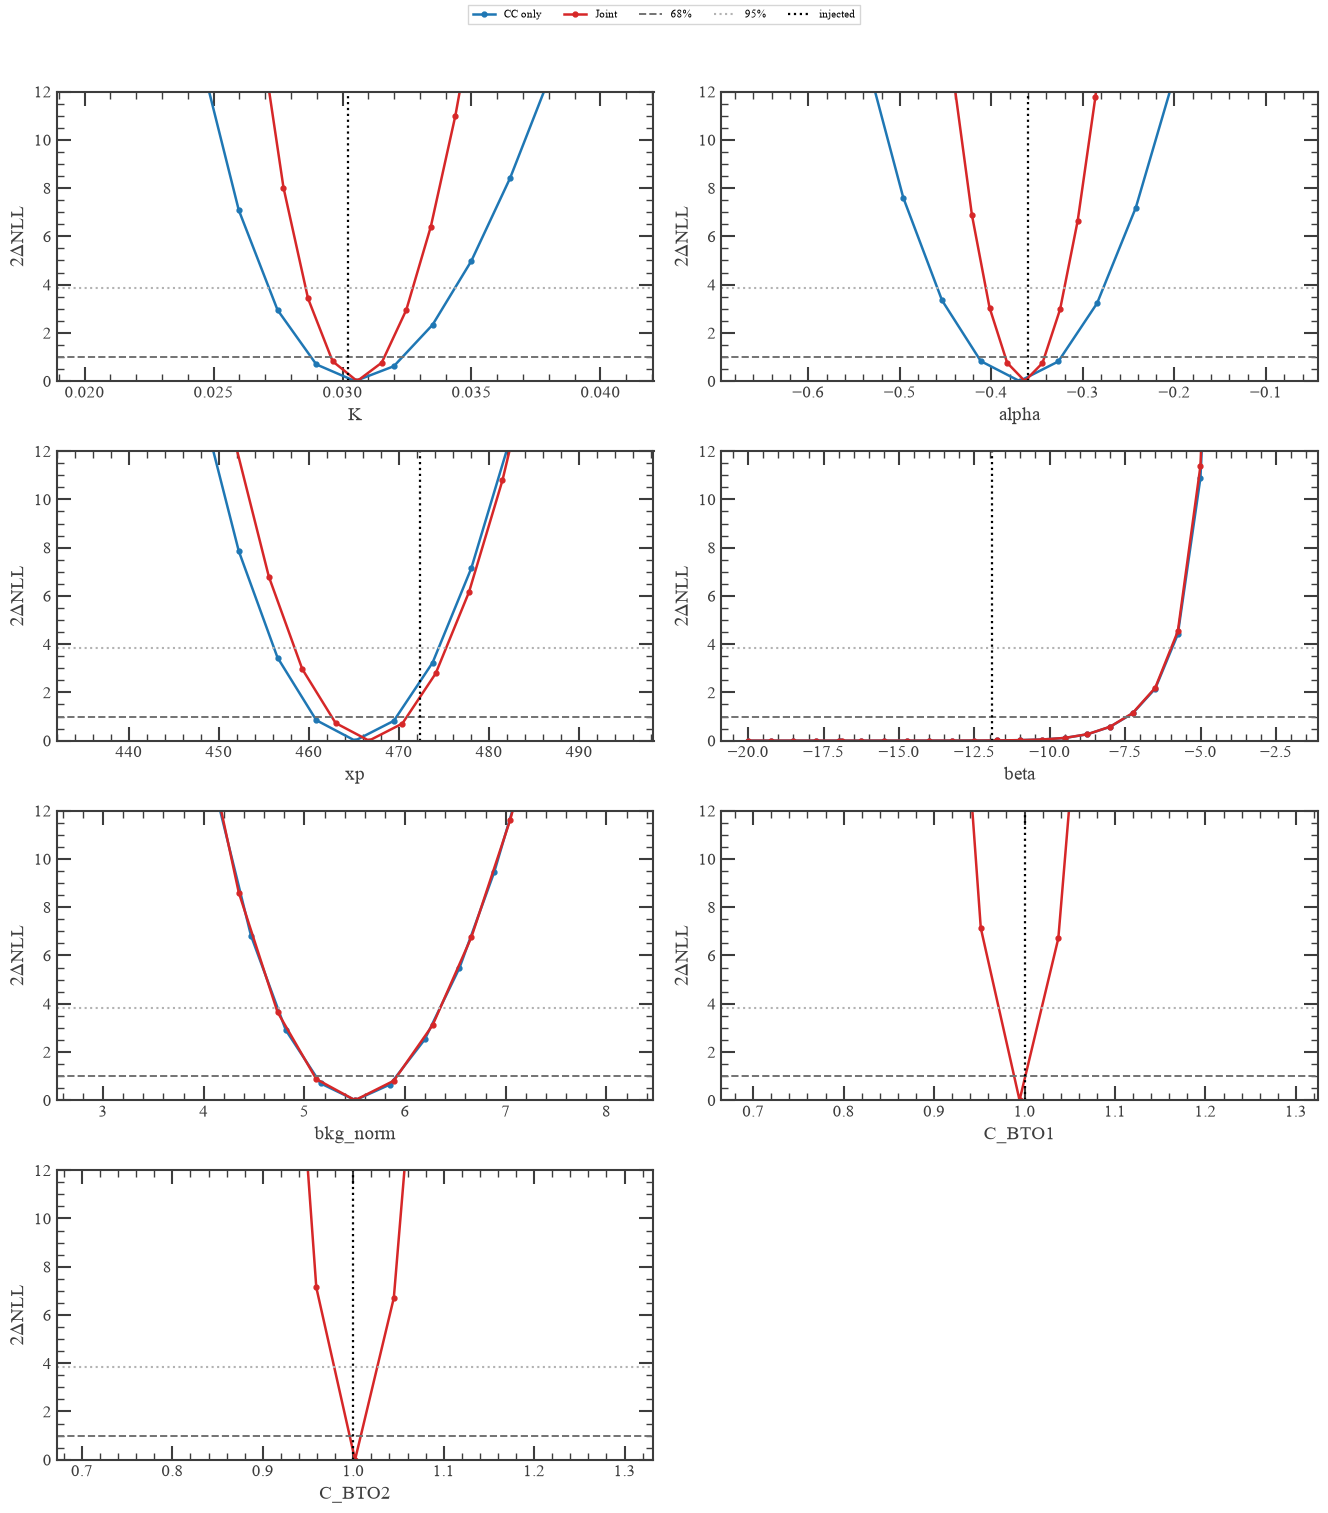

In [11]:
profile_truth = {**injected_band, 'C_BTO1': 1.0, 'C_BTO2': 1.0}
parameter_order = list(band_parameter_names) + ['bkg_norm']
parameter_order += ['C_BTO1', 'C_BTO2']

profile_parameter_sources = {
    'CC only': cc_profile_parameters,
    'Joint': joint_profile_parameters,
}
rows = []
for name in parameter_order:
    for dataset_name, best_values, profile in (
        ('CC only', cc_best_values, cc_profile),
        ('Joint', joint_best_values, joint_profile),
    ):
        if name not in best_values:
            continue
        best = float(best_values[name])
        parameter = profile_parameter_sources[dataset_name][name]
        lower68, lower68_limited = profile_limit(profile, name, best, DELTA_STAT_68, 'lower', parameter)
        upper68, upper68_limited = profile_limit(profile, name, best, DELTA_STAT_68, 'upper', parameter)
        lower95, lower95_limited = profile_limit(profile, name, best, DELTA_STAT_95, 'lower', parameter)
        upper95, upper95_limited = profile_limit(profile, name, best, DELTA_STAT_95, 'upper', parameter)
        rows.append({
            'dataset': dataset_name,
            'parameter': name,
            'best_fit': best,
            'lower_68': lower68,
            'upper_68': upper68,
            'lower_95': lower95,
            'upper_95': upper95,
            'lower_68_bound_limited': lower68_limited,
            'upper_68_bound_limited': upper68_limited,
            'lower_95_bound_limited': lower95_limited,
            'upper_95_bound_limited': upper95_limited,
        })
intervals = pd.DataFrame(rows)
display(intervals)

combined_profile = pd.concat([cc_profile, joint_profile], ignore_index=True)
n_parameters = len(parameter_order)
n_columns = 2
n_rows = math.ceil(n_parameters/n_columns)
fig, axes = plt.subplots(n_rows, n_columns, figsize=(13.5, 3.8*n_rows), squeeze=False)
colors = {'CC only': 'tab:blue', 'Joint': 'tab:red'}
profile_sources = {'CC only': cc_profile, 'Joint': joint_profile}
for ax, name in zip(axes.flat, parameter_order):
    for dataset_name, profile in profile_sources.items():
        selected = profile[(profile.parameter == name) & np.isfinite(profile.twice_delta_nll)].sort_values('fixed_value')
        if len(selected):
            ax.plot(selected.fixed_value, selected.twice_delta_nll, marker='o', ms=3.5,
                    color=colors[dataset_name], lw=1.8, label=dataset_name)
    ax.axhline(DELTA_STAT_68, color='0.45', ls='--', lw=1.4, label='68%')
    ax.axhline(DELTA_STAT_95, color='0.7', ls=':', lw=1.5, label='95%')
    if name in profile_truth:
        ax.axvline(profile_truth[name], color='black', ls=':', lw=1.6, label='injected')
    ax.set(xlabel=name, ylabel=r'$2\Delta$NLL', ylim=(0, 12))
    style_axes(ax)
for ax in axes.flat[n_parameters:]:
    ax.axis('off')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, frameon=True)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(output_path/'profile_likelihood_comparison.png', dpi=180)
plt.show()

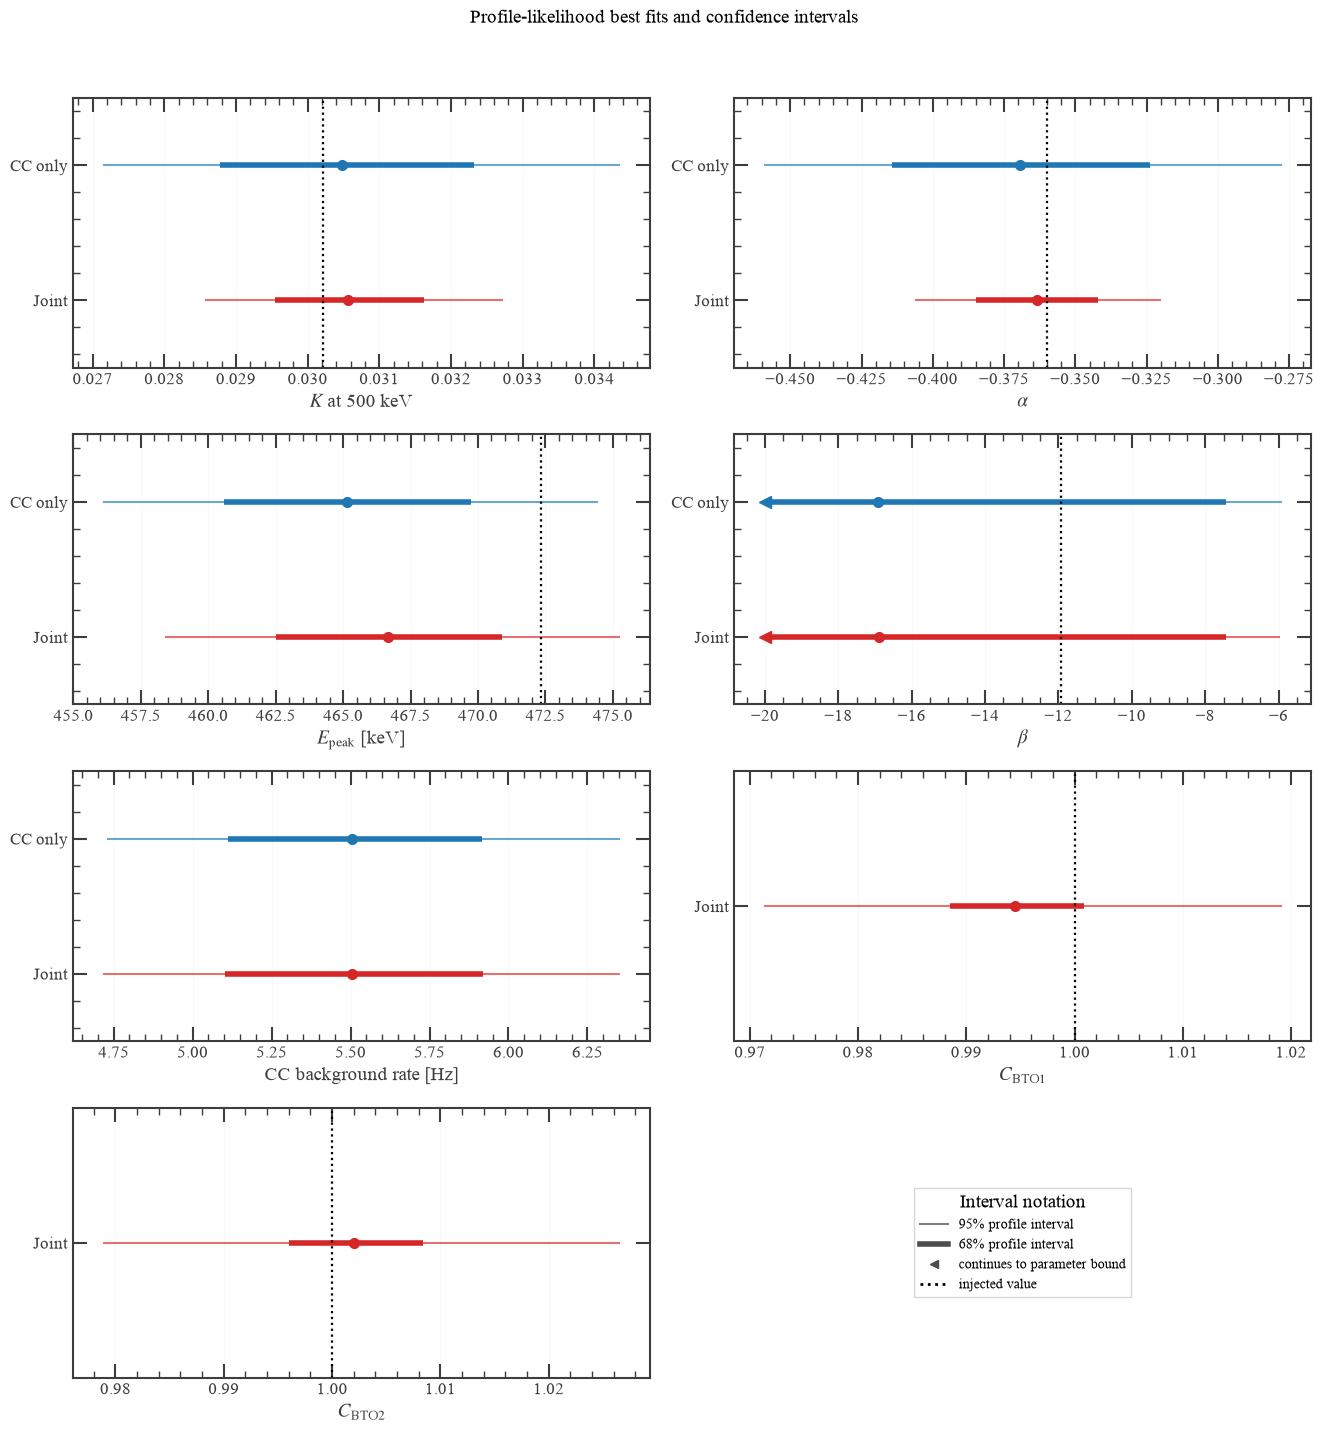

In [12]:
parameter_labels = {'K': r'$K$ at 500 keV', 'alpha': r'$\alpha$',
                    'xp': r'$E_{\rm peak}$ [keV]', 'beta': r'$\beta$',
                    'bkg_norm': 'CC background rate [Hz]',
                    'C_BTO1': r'$C_{\rm BTO1}$', 'C_BTO2': r'$C_{\rm BTO2}$'}
fig, axes = plt.subplots(math.ceil(len(parameter_order)/2), 2,
                         figsize=(13.5, 3.6*math.ceil(len(parameter_order)/2)), squeeze=False)
for ax, name in zip(axes.flat, parameter_order):
    selected = intervals[intervals.parameter == name].reset_index(drop=True)
    for y, row in selected.iterrows():
        best = float(row.best_fit)
        lower68, upper68 = float(row.lower_68), float(row.upper_68)
        lower95, upper95 = float(row.lower_95), float(row.upper_95)
        color = 'tab:blue' if row.dataset == 'CC only' else 'tab:red'

        # Thin outer line = 95% interval; thick inner line = 68% interval. No shaded band here.
        if np.isfinite(lower95) and np.isfinite(upper95):
            ax.plot([lower95, upper95], [y, y], color=color, alpha=0.65, lw=1.5)
        if np.isfinite(lower68) and np.isfinite(upper68):
            ax.plot([lower68, upper68], [y, y], color=color, lw=4.0, solid_capstyle='butt')
        ax.plot(best, y, 'o', ms=7, color=color, zorder=4)

        # A triangle at a scan/physical bound means that the confidence region
        # continues to that bound: it is a one-sided constraint, not zero error.
        if bool(row.lower_95_bound_limited) and np.isfinite(lower95):
            ax.plot(lower95, y, marker='<', ms=8, color=color, clip_on=False)
        if bool(row.upper_95_bound_limited) and np.isfinite(upper95):
            ax.plot(upper95, y, marker='>', ms=8, color=color, clip_on=False)

    if name in profile_truth:
        ax.axvline(profile_truth[name], color='black', ls=':', lw=1.6)
    ax.set_yticks(range(len(selected)), selected.dataset.tolist())
    ax.set_xlabel(parameter_labels[name])
    ax.set_ylim(len(selected)-0.5, -0.5)
    ax.grid(axis='x', alpha=0.15)
    ax.margins(x=0.06)
    style_axes(ax)
legend_handles = [
    Line2D([0], [0], color='0.5', lw=1.5, label='95% profile interval'),
    Line2D([0], [0], color='0.3', lw=4, label='68% profile interval'),
    Line2D([0], [0], marker='<', color='0.3', lw=0, label='continues to parameter bound'),
    Line2D([0], [0], color='black', ls=':', label='injected value'),
]
for ax in axes.flat[len(parameter_order):]:
    ax.axis('off')
axes.flat[-1].legend(
    handles=legend_handles,
    loc='center',
    frameon=True,
    title='Interval notation',
    fontsize=10,
)
fig.suptitle('Profile-likelihood best fits and confidence intervals', y=0.995, fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.975))
fig.savefig(output_path/'profile_parameter_comparison.png', dpi=180)
fig.savefig(output_path/'parameter_error_comparison.png', dpi=180)
plt.show()

#### 12. Photon-space comparison with a profile-range envelope

The translucent blue/red band belongs on the **photon spectrum**. To reproduce
the reference figure, we evaluate the best-fit Band model and then move each of
`K`, `alpha`, `xp`, and `beta` separately to its lower/upper 95% profile endpoint,
holding the other spectral parameters at their best-fit values. The minimum
and maximum of these curves at each energy define the displayed envelope.
All curves and envelope arrays remain in memory below.

The endpoints use $2\Delta\mathrm{NLL}=3.841459$ (one profiled parameter).
The label "95% profile-range envelope" identifies its construction; it is an
illustration of the marginal parameter ranges. Combining endpoints
this way does not propagate the full parameter covariance. 

If a beta interval reaches -20, its envelope is truncated by that chosen bound;
the bound is not a measured lower limit. Above the BTO response's maximum true
energy (3000 keV here), the plotted Band spectrum is the model constrained by
the available CC data

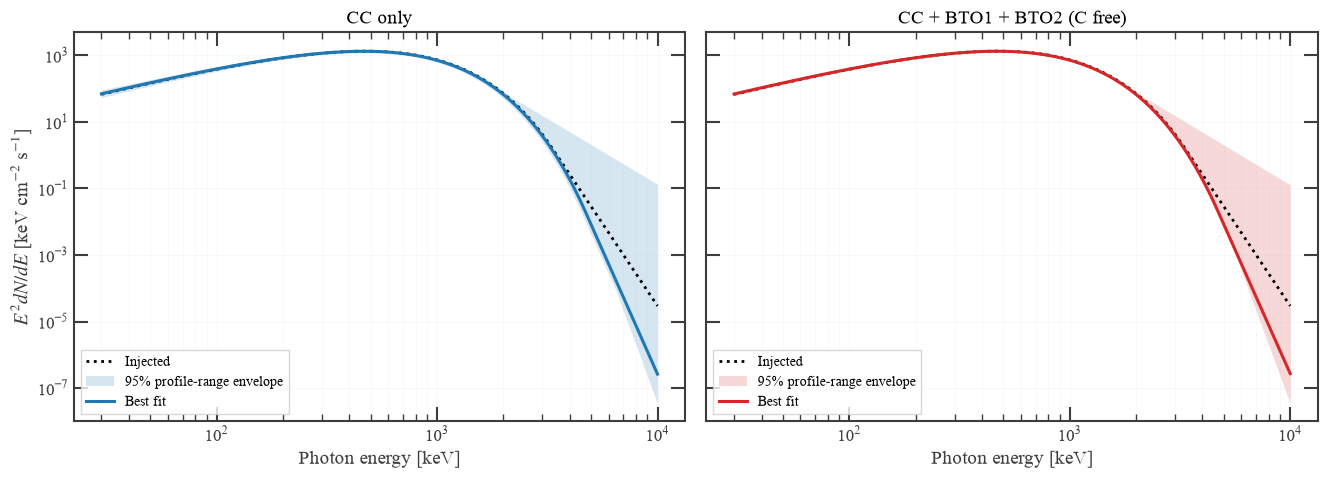

In [13]:
def evaluate_sed(values, energy_keV):
    """Evaluate E^2 dN/dE while restoring the shared fit model afterwards."""
    saved = get_band()
    try:
        set_band(values)
        return energy_keV**2*np.asarray(spectrum(energy_keV), float)
    finally:
        set_band(saved)

injected_sed = evaluate_sed(injected_band, energy_plot)
spectral_best = {'CC only': cc_best_band, 'Joint': joint_best_band}
spectral_curves = {}
spectral_envelopes = {}
for dataset, best in spectral_best.items():
    # Reference-figure construction: vary ONE Band parameter at a time using
    # its 95% profile endpoints, then take the outer envelope of those spectra.
    curves = [evaluate_sed(best, energy_plot)]
    selected = intervals[(intervals.dataset == dataset)
                         & intervals.parameter.isin(band_parameter_names)]
    if len(selected) != len(band_parameter_names):
        raise RuntimeError(f'Missing spectral profile intervals for {dataset}')
    for _, row in selected.iterrows():
        for endpoint in ('lower_95', 'upper_95'):
            if not np.isfinite(row[endpoint]):
                raise RuntimeError(f'Expand the {dataset} {row.parameter} scan before plotting its envelope')
            varied = dict(best)
            varied[row.parameter] = float(row[endpoint])
            curves.append(evaluate_sed(varied, energy_plot))
    spectral_curves[dataset] = np.asarray(curves)
    spectral_envelopes[dataset] = (
        spectral_curves[dataset].min(axis=0),
        spectral_curves[dataset].max(axis=0),
    )
    lower, upper = spectral_envelopes[dataset]
    assert np.all(np.isfinite(spectral_curves[dataset]))
    assert np.all((lower >= 0) & (upper >= lower))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), sharex=True, sharey=True)
for ax, dataset, title, color in (
    (axes[0], 'CC only', 'CC only', 'tab:blue'),
    (axes[1], 'Joint', 'CC + BTO1 + BTO2 (C free)', 'tab:red'),
):
    lower, upper = spectral_envelopes[dataset]
    ax.plot(energy_plot, injected_sed, color='black', ls=':', lw=2, label='Injected')
    ax.fill_between(energy_plot, np.maximum(lower, 1e-300), np.maximum(upper, 1e-300),
                    color=color, alpha=0.18, linewidth=0, label='95% profile-range envelope')
    ax.plot(energy_plot, spectral_curves[dataset][0], color=color, lw=2.2, label='Best fit')
    ax.set(xscale='log', yscale='log', xlabel='Photon energy [keV]')
    ax.set_title(title, fontsize=14)
    ax.grid(which='both', alpha=0.15)
    ax.legend(frameon=True, fontsize=10, loc='lower left')
    style_axes(ax)
axes[0].set_ylabel(r'$E^2 dN/dE$ [keV cm$^{-2}$ s$^{-1}$]')
fig.tight_layout()
fig.savefig(output_path/'photon_spectrum_comparison_separate.png', dpi=180)
plt.show()

#### 13. CC, BTO1, and BTO2 count-space comparison

Each instrument remains on its own fitted measured-energy bins. The upper panel shows count-rate density and the lower panel shows Pearson residuals. Observed spectra are plotted with error bars, while source+background and background-only predictions are separate curves.

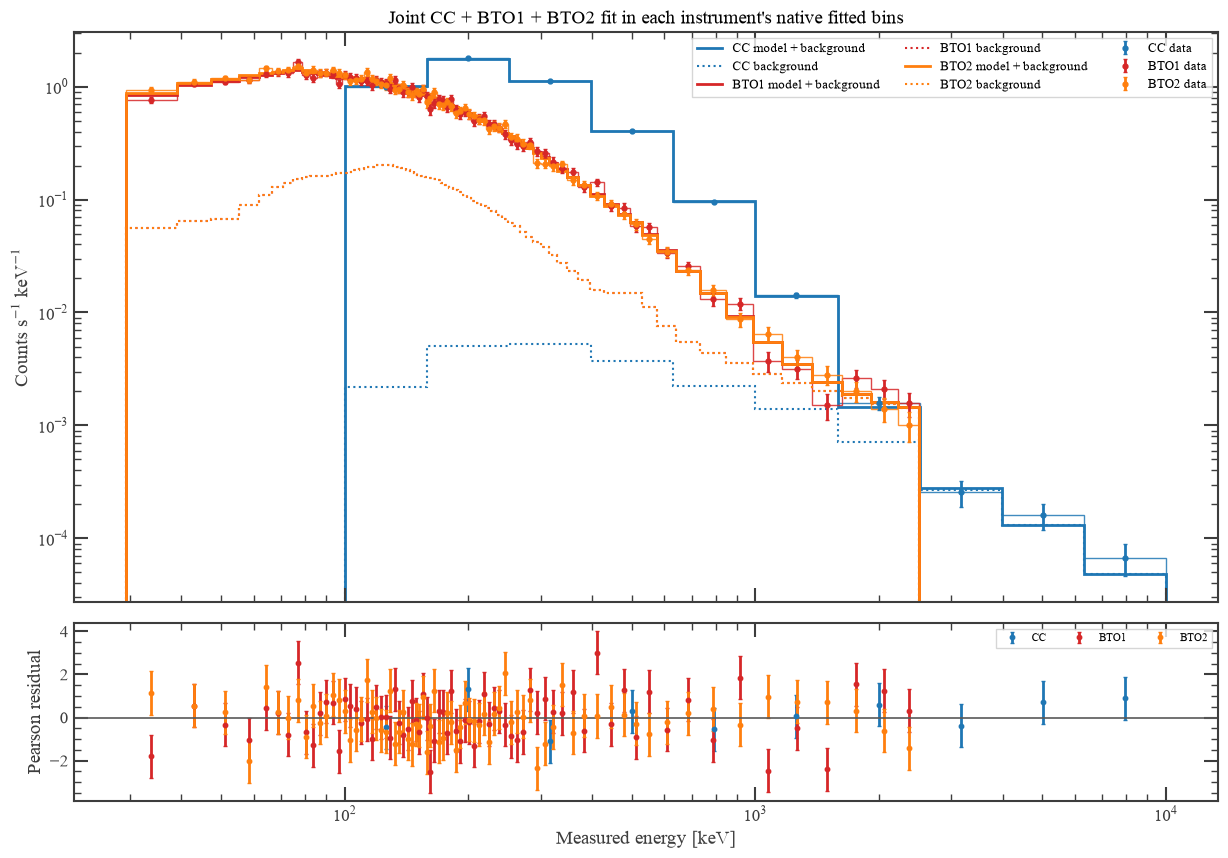

All notebook products: /Users/shunsaku/work/COSI/sim_solar_cosipy/tutorial_grb_fit_with_bto_response/notebook_output/free_crossnorm


In [14]:
# Restore the joint best-fit state before asking each plugin for its prediction.
set_band(joint_best_band)
cc_plugin.bkg_parameter['bkg_norm'].value = joint_best_background_hz
cc_folding.set_model(model)
for detector_name, value in joint_cross_norms.items():
    parameter = bto_plugins[detector_name].nuisance_parameters[f'cons_{bto_plugins[detector_name].name}']
    parameter.value = value

cc_observed_projection = cc_data.data.project('Em')
cc_source_projection = cc_folding.expectation().project('Em')
cc_background_projection = cc_background_model.expectation().project('Em')
cc_edges = np.asarray(cc_observed_projection.axes['Em'].edges.to_value(u.keV))

series = [{
    'name': 'CC', 'color': 'tab:blue', 'edges': cc_edges,
    'observed': np.asarray(cc_observed_projection.contents, float),
    'source': np.asarray(cc_source_projection.contents, float),
    'background': np.asarray(cc_background_projection.contents, float),
    'exposure': cc_livetime_s,
}]
for detector_name, color in (('BTO1', 'tab:red'), ('BTO2', 'tab:orange')):
    plugin = bto_plugins[detector_name]
    low, high = plugin.energy_boundaries
    edges = np.concatenate(([float(low[0])], np.asarray(high, float)))
    series.append({
        'name': detector_name, 'color': color, 'edges': edges,
        'observed': np.asarray(plugin.current_observed_counts, float),
        'source': np.asarray(plugin.get_model(), float),
        'background': np.asarray(plugin.current_scaled_background_counts, float),
        'exposure': float(plugin.exposure),
    })

fig, (ax, residual_ax) = plt.subplots(2, 1, figsize=(12.5, 8.8), sharex=True,
                                      gridspec_kw={'height_ratios': [3.2, 1.0]})
for item in series:
    edges = item['edges']
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1]*edges[1:])
    observed = item['observed']
    total = item['source'] + item['background']
    scale = item['exposure']*widths
    observed_density = observed/scale
    total_density = total/scale
    background_density = item['background']/scale
    ax.stairs(observed_density, edges, color=item['color'], lw=1.0, alpha=0.85)
    ax.errorbar(centers, observed_density, yerr=np.sqrt(np.clip(observed, 1.0, None))/scale,
                fmt='o', ms=3.5, color=item['color'], capsize=1.5, label=f"{item['name']} data")
    ax.stairs(total_density, edges, color=item['color'], lw=2.0, label=f"{item['name']} model + background")
    ax.stairs(background_density, edges, color=item['color'], lw=1.5, ls=':', label=f"{item['name']} background")
    residual = (observed-total)/np.sqrt(np.clip(observed, 1.0, None))
    residual_ax.errorbar(centers, residual, yerr=np.ones_like(residual), fmt='o', ms=3.2,
                         color=item['color'], capsize=1.2, label=item['name'])

ax.set(xscale='log', yscale='log', ylabel=r'Counts s$^{-1}$ keV$^{-1}$',
       title="Joint CC + BTO1 + BTO2 fit in each instrument's native fitted bins")
ax.legend(ncol=3, fontsize=9, frameon=True)
residual_ax.axhline(0.0, color='0.35', lw=1.2)
residual_ax.set(xscale='log', xlabel='Measured energy [keV]', ylabel='Pearson residual')
residual_ax.legend(ncol=3, frameon=True)
style_axes(ax)
style_axes(residual_ax)
fig.tight_layout()
fig.savefig(output_path/'cc_bto1_bto2_count_spectrum_overlay.png', dpi=180)
plt.show()

print('All notebook products:', output_path)